## Linear Model Assumptions: What They Mean, When They Fail, and How to Check Them

Linear models such as **Linear Regression**, **Logistic Regression**, and **regularized linear models** are widely used in industry because they are fast, stable, and interpretable. However, their reliability depends on several underlying assumptions about the data. These assumptions are not strict rules, but guidelines that help ensure meaningful estimates and trustworthy inference.

Understanding _why_ these assumptions exist and _what happens when they are violated_ is far more important than enforcing them perfectly.

---

### Linearity

Linear models assume that the expected value of the target variable changes **linearly** with each feature, holding other features constant. This does not mean the data must form a straight line, but rather that the relationship can be approximated by a linear combination of features.

This assumption is commonly violated when the true relationship is curved, has thresholds, or involves interactions that are not explicitly modeled. For example, income often increases rapidly early in a career and then plateaus, which is not linear.

Linearity is usually checked using scatter plots and residual-versus-prediction plots. If residuals show systematic patterns or curves, the linearity assumption is likely broken. In practice, this is addressed by feature engineering (polynomial terms, interactions, log transformations) or by switching to non-linear models such as tree-based methods.

---

### Independence of Errors

Linear models assume that residuals are independent of one another. This assumption is especially important for time series and grouped data. When observations are correlated over time or within groups, the model tends to underestimate uncertainty and overstate confidence.

Violations often appear in temporal data (e.g., daily sales, sensor readings) where yesterday’s error influences today’s. This can be diagnosed by plotting residuals over time or using statistical tests for autocorrelation.

In industry, this assumption is often handled by adding lag features, using time-aware models, or applying clustered or mixed-effects models rather than plain linear regression.

---

### Constant Variance (Homoscedasticity)

Linear models assume that residuals have **constant variance** across all levels of prediction. When this is not true, the model fits some regions well but performs poorly in others.

Heteroscedasticity commonly occurs in financial data, where variance increases with the magnitude of the target (e.g., higher income → more variability). This issue is usually detected using residual-versus-fitted plots, where a funnel-shaped pattern indicates increasing variance.

Typical remedies include transforming the target variable (e.g., log transformation), using weighted regression, or relying on robust standard errors.

---

### Normality of Errors

The normality assumption applies to the **distribution of residuals**, not the features themselves. It mainly affects statistical inference such as confidence intervals and hypothesis testing, not predictive performance.

In real-world data, residuals are often skewed or heavy-tailed due to outliers or data truncation. This is evaluated using histograms or Q–Q plots of residuals.

In practice, strict normality is rarely required. When inference matters, transformations or robust regression techniques are used. For prediction-focused tasks, this assumption is often ignored.

---

### Multicollinearity

Linear models assume that features are not highly correlated with one another. When predictors are strongly correlated, coefficient estimates become unstable and difficult to interpret, even though predictions may remain accurate.

Multicollinearity is common when using engineered features, dummy variables, or measurements capturing similar concepts. It is typically diagnosed using correlation matrices or variance inflation factors (VIF).

Industry solutions include removing redundant features, combining correlated variables, or applying regularization methods such as Ridge or Lasso regression.

---

### Sensitivity to Outliers

Linear models are sensitive to extreme values because they minimize squared errors. A small number of outliers can significantly influence coefficients and predictions.

Outliers are identified through visual inspection, leverage statistics, or influence measures. Rather than blindly removing them, practitioners first determine whether they are errors or meaningful rare events.

Common treatments include capping extreme values, transforming features, adding outlier indicators, or using robust linear models that reduce the influence of extreme observations.

---

### Industry Perspective

In practice, **linear model assumptions are rarely perfectly satisfied**. Instead of abandoning linear models, practitioners focus on diagnostics, feature engineering, and robustness techniques. Linear models remain popular because their behavior is predictable, explainable, and easy to control.

The goal is not to satisfy every assumption exactly, but to ensure that violations do not meaningfully harm conclusions or decisions.

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [2]:
# Create Example Data

np.random.seed(42)

n = 200
X1 = np.random.normal(50, 10, n)
X2 = X1 * 0.9 + np.random.normal(0, 2, n)   # correlated feature
noise = np.random.normal(0, X1 * 0.2)       # heteroscedastic noise

y = 2 * X1 + noise

df = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'y': y
})

df

,X1,X2,y
0,54.967142,50.186002,92.406057
1,48.617357,44.877190,91.406708
2,56.476885,52.995299,113.013000
3,65.230299,60.814873,131.073509
4,47.658466,40.137281,91.027046
...,...,...,...
195,53.853174,47.529505,102.213147
196,41.161426,33.619014,80.101164
197,51.537251,49.091271,92.985944
198,50.582087,45.294799,96.669518


In [3]:
# Fit a Linear Model
X = df[['X1', 'X2']]
y = df['y']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
residuals = y - y_pred
residuals

0     -15.592518
1      -4.897094
2       2.213753
3       4.146076
4      -3.459571
         ...    
195    -3.711366
196    -2.405365
197    -8.718620
198    -3.236936
199     2.242333
Name: y, Length: 200, dtype: float64

### Linearity Check (Residuals vs Predictions)


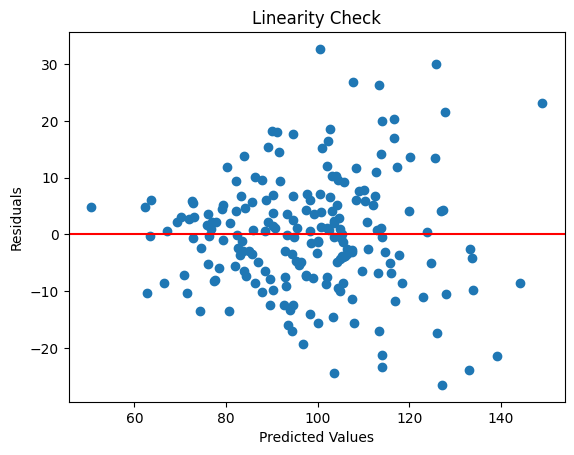

In [4]:
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Linearity Check")
plt.show()


- Random scatter → linearity
- Curved or structured pattern → non-linearity

### Homoscedasticity Check (Constant Variance)


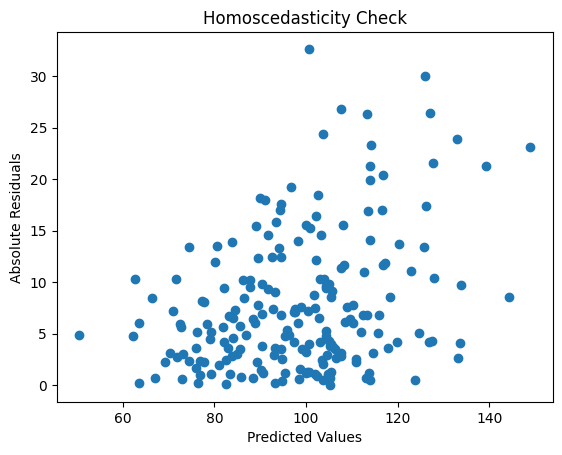

In [5]:
plt.scatter(y_pred, np.abs(residuals))
plt.xlabel("Predicted Values")
plt.ylabel("Absolute Residuals")
plt.title("Homoscedasticity Check")
plt.show()

- Constant spread → linearity
- Funnel shape → heteroscedasticity

For the plot above:

- No sharp funnel or cone

- But a mild upward spread as predictions increase

- High values have more large residuals than low values

- This is not severe, but it is not perfectly constant variance either.

The plot of absolute residuals versus fitted values suggests mild heteroscedasticity, with a slight increase in residual spread at higher predicted values. However, the pattern is not strong or severe.

### Normality of residuals


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


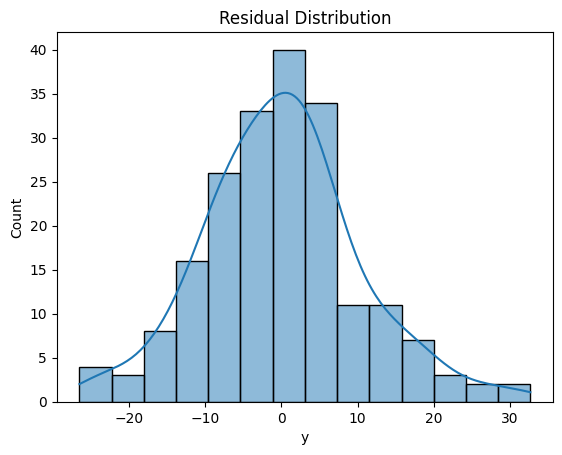

In [6]:
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

- Heavy tails or skew → normality violated

### Outlier detection

If residuals are approximately normally distributed, then:

- $|z| > 3$ → very extreme (≈ 0.3% of data)

- $|z| > 2$ → moderately extreme (≈ 5% of data)


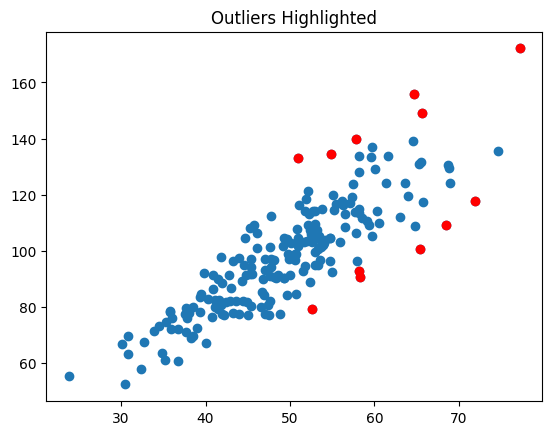

In [7]:
plt.scatter(df['X1'], df['y'])
plt.scatter(df.loc[np.abs(residuals) > 2*np.std(residuals), 'X1'],
            df.loc[np.abs(residuals) > 2*np.std(residuals), 'y'],
            color='red')
plt.title("Outliers Highlighted")
plt.show()


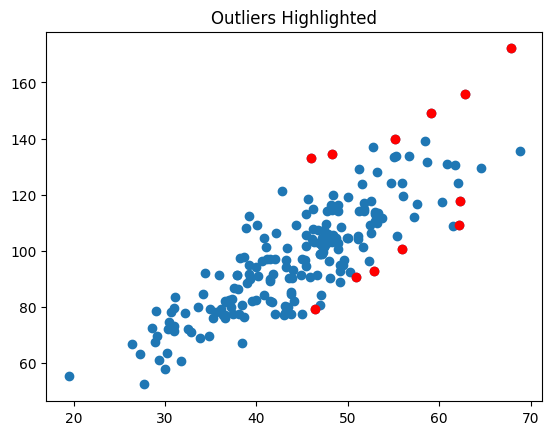

In [8]:
plt.scatter(df['X2'], df['y'])
plt.scatter(df.loc[np.abs(residuals) > 2*np.std(residuals), 'X2'],
            df.loc[np.abs(residuals) > 2*np.std(residuals), 'y'],
            color='red')
plt.title("Outliers Highlighted")
plt.show()


### Multicollinearity

Correlation measures the linear relationship between two variables at a time, giving a value between `-1` and `1` that indicates how closely they move together, but it ignores the effect of all other features in the dataset. VIF, on the other hand, quantifies how much a feature is explained by all the other features collectively; it is calculated by regressing the feature on the remaining variables and computing $\frac{1}{1-R^2}$, so a high VIF indicates strong multicollinearity that could affect regression models. While correlation is useful for quickly spotting pairwise relationships, VIF gives a more complete picture of redundancy among features and is especially important when preparing data for linear regression.


In [9]:
corr_matrix = df.corr()
corr_matrix

,X1,X2,y
X1,1.000000,0.974687,0.858842
X2,0.974687,1.000000,0.837388
y,0.858842,0.837388,1.000000


**VIF Concept**

VIF measures how much a feature is correlated with other features.  
Formula for feature $X_i$:

$$
\text{VIF}_i = \frac{1}{1 - R_i^2}
$$

Where $R_i^2$ is the $R^2$ from regressing $X_i$ on all other features.


In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

df = add_constant(df)
df

,const,X1,X2,y
0,1.0,54.967142,50.186002,92.406057
1,1.0,48.617357,44.877190,91.406708
2,1.0,56.476885,52.995299,113.013000
3,1.0,65.230299,60.814873,131.073509
4,1.0,47.658466,40.137281,91.027046
...,...,...,...,...
195,1.0,53.853174,47.529505,102.213147
196,1.0,41.161426,33.619014,80.101164
197,1.0,51.537251,49.091271,92.985944
198,1.0,50.582087,45.294799,96.669518


In [11]:
X = df.drop(columns='y')
X

,const,X1,X2
0,1.0,54.967142,50.186002
1,1.0,48.617357,44.877190
2,1.0,56.476885,52.995299
3,1.0,65.230299,60.814873
4,1.0,47.658466,40.137281
...,...,...,...
195,1.0,53.853174,47.529505
196,1.0,41.161426,33.619014
197,1.0,51.537251,49.091271
198,1.0,50.582087,45.294799


In [12]:
[variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

[29.695651259482112, 20.006176512622222, 20.00617651262218]

- VIF > 10 → indicates strong multicollinearity.
- In our case, all three features have extremely high VIFs.

A VIF higher than 10 is generally considered a warning sign of severe multicollinearity. The threshold of 10 for VIF is mostly conventional rather than a strict rule.
